In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import mne
from mne.datasets.sleep_physionet.age import fetch_data
import warnings

# Suppress MNE verbosity for cleaner output
warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
from huggingface_hub import snapshot_download

# This pulls the already preprocessed data directly into your local folder
snapshot_download(
    repo_id="eth-siplab/Learning-with-FrameProjections", 
    repo_type="dataset",
    local_dir="./data"
)

Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 2325.15it/s]


'/home/gella.saikrishna/code/Learning-with-FrameProjections/data'

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader

class SleepEDF_HF_Dataset(Dataset):
    def __init__(self, pt_file_path, split="train"):
        """
        Loads the preprocessed Sleep-EDF dataset from a Hugging Face .pt file.
        split: 'train', 'test', or 'val' (if the file is divided into subsets)
        """
        print(f"Loading Hugging Face dataset from {pt_file_path}...")
        
        # 1. Load the PyTorch file
        data_obj = torch.load(pt_file_path)
        
        # 2. Extract the sequences from nested dictionaries
        if isinstance(data_obj, dict):
            # Check if data is nested by train/test/val splits
            if split in data_obj and isinstance(data_obj[split], dict):
                print(f"Found '{split}' split, extracting...")
                data_obj = data_obj[split] # Dig one level deeper into the dictionary
                
            # Now extract the actual tensor from the current dictionary level
            if "samples" in data_obj:
                self.data = data_obj["samples"]
            elif "data" in data_obj:
                self.data = data_obj["data"]
            elif "x_data" in data_obj:
                self.data = data_obj["x_data"]
            elif "X_train" in data_obj:
                self.data = data_obj["X_train"]
            else:
                # If the keys are completely unusual, this will print them so we can fix it
                raise ValueError(f"Could not find the tensor. Available keys are: {data_obj.keys()}")
        else:
            self.data = data_obj
            
        # 3. Ensure it is a FloatTensor
        if not isinstance(self.data, torch.Tensor):
            self.data = torch.FloatTensor(self.data)
        else:
            self.data = self.data.float()
            
        # 4. Squeeze extra channel dimension if it exists (e.g., [N, 1, 3000] -> [N, 3000])
        if self.data.dim() == 3 and self.data.shape[1] == 1:
            self.data = self.data.squeeze(1)

        print(f"✅ Successfully loaded {len(self.data)} epochs.")
        print(f"   Raw tensor shape: {self.data.shape}")
        
        # Pre-compute the Hann window for the Gabor/Wavelet transform
        self.window = torch.hann_window(128)
        
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        x_t = self.data[idx] 
        
        # 1. TIME DOMAIN
        x_time = x_t.unsqueeze(0) 
        
        # 2. FOURIER DOMAIN
        x_fft = torch.fft.rfft(x_t)
        magnitude = torch.abs(x_fft)
        phase = torch.angle(x_fft)
        x_fourier = torch.stack([magnitude, phase], dim=0)
        
        # 3. WAVELET / GABOR DOMAIN
        x_stft = torch.stft(x_t, n_fft=128, hop_length=64, window=self.window, return_complex=True)
        x_wavelet = torch.abs(x_stft).unsqueeze(0) 
        
        return x_time, x_fourier, x_wavelet

# --- Test the Dataloader ---
# Note: we can now pass the split="train" argument
file_path = "/home/gella.saikrishna/code/Learning-with-FrameProjections/data/sleep_combined.pt"
train_dataset = SleepEDF_HF_Dataset(pt_file_path=file_path, split="train")

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, drop_last=True)
batch_t, batch_f, batch_w = next(iter(train_loader))

print("\n--- Model Input Shapes ---")
print(f"Time Input:    {batch_t.shape}")
print(f"Fourier Input: {batch_f.shape}")
print(f"Wavelet Input: {batch_w.shape}")

Loading Hugging Face dataset from /home/gella.saikrishna/code/Learning-with-FrameProjections/data/sleep_combined.pt...
Found 'train' split, extracting...
✅ Successfully loaded 25612 epochs.
   Raw tensor shape: torch.Size([25612, 3000])

--- Model Input Shapes ---
Time Input:    torch.Size([64, 1, 3000])
Fourier Input: torch.Size([64, 2, 1501])
Wavelet Input: torch.Size([64, 1, 65, 47])


In [4]:
import torch

# Dataset path
dataset_path = "/home/gella.saikrishna/code/Learning-with-FrameProjections/data/sleep_combined.pt"

# Load dictionary
data_obj = torch.load(dataset_path, map_location="cpu")

print("--- Split Content Summary ---")
for split in ["train", "val", "test"]:
    if split in data_obj:
        split_dict = data_obj[split]
        
        # Extract samples and labels tensors
        samples = split_dict.get("samples", None)
        labels = split_dict.get("labels", None)
        
        print(f"\nSplit '{split}':")
        if samples is not None:
            print(f"  -> Total Epochs (Samples): {samples.shape[0]}")
            print(f"  -> Sample Dimensions:     {list(samples.shape)}")
        if labels is not None:
            # If it is a PyTorch tensor, find the unique classification categories
            if isinstance(labels, torch.Tensor):
                unique_classes = torch.unique(labels).tolist()
            else:
                unique_classes = list(set(labels))
            print(f"  -> Target Labels Found:   {len(labels)} values across {len(unique_classes)} unique sleep stages ({unique_classes})")
    else:
        print(f"Split '{split}' not found.")

--- Split Content Summary ---

Split 'train':
  -> Total Epochs (Samples): 25612
  -> Sample Dimensions:     [25612, 1, 3000]
  -> Target Labels Found:   25612 values across 5 unique sleep stages ([0, 1, 2, 3, 4])

Split 'val':
  -> Total Epochs (Samples): 7786
  -> Sample Dimensions:     [7786, 1, 3000]
  -> Target Labels Found:   7786 values across 5 unique sleep stages ([0, 1, 2, 3, 4])

Split 'test':
  -> Total Epochs (Samples): 8910
  -> Sample Dimensions:     [8910, 1, 3000]
  -> Target Labels Found:   8910 values across 5 unique sleep stages ([0, 1, 2, 3, 4])


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

# Import the classes from your files
from models.models_nc import ResNet1D, FourierEncoder, UNET_2D_simp
from models.frameworks import IsoAlign

# ---------------------------------------------------------
# 1. Hyperparameters & Device Setup
# ---------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
TIME_STEPS = 200     # Example sequence length
TIME_CHANNELS = 1    # 1D Time series channel
FT_CHANNELS = 2      # Magnitude & Phase for Fourier
SPECT_FREQ = 48      # Spectrogram frequency bins
LATENT_DIM = 128     # Output dimension for the projection heads

# Note: Create a dummy args class to pass required arguments
class Args:
    wo_OB = False
    wo_OF = False

args = Args()

# ---------------------------------------------------------
# 2. Instantiate the Encoders (Backbones)
# ---------------------------------------------------------
# A. Time Domain Encoder (1D ResNet)
# output_dim=128 to match our latent space projection
time_encoder = ResNet1D(
    in_channels=TIME_CHANNELS, 
    base_filters=32, 
    kernel_size=5, 
    stride=1, 
    groups=1, 
    n_block=3, 
    n_classes=LATENT_DIM, 
    downsample_gap=2, 
    increasefilter_gap=4, 
    use_do=True, 
    backbone=True, 
    output_dim=LATENT_DIM
).to(DEVICE)

# B. Spectrogram / Wavelet Encoder (2D UNet)
# Processes the time-frequency representation
spect_encoder = UNET_2D_simp(
    input_channels=1, 
    output_channels=LATENT_DIM, 
    layer_n=32, 
    spect_freq=SPECT_FREQ, 
    spect_time=TIME_STEPS, 
    kernel_size=3
).to(DEVICE)

# C. Fourier Domain Encoder (1D Convolutional setup)
# Needs a small wrapper to return a tuple since IsoAlign expects `_, R_f_FT = self.FT_encoder(x3)`
class FourierWrapper(nn.Module):
    def __init__(self, in_channels, in_length, out_channels):
        super().__init__()
        self.enc = FourierEncoder(in_channels, in_length, out_channels)
    def forward(self, x):
        return None, self.enc(x)

ft_encoder = FourierWrapper(
    in_channels=FT_CHANNELS, 
    in_length=TIME_STEPS, 
    out_channels=LATENT_DIM
).to(DEVICE)

# ---------------------------------------------------------
# 3. Instantiate the IsoAlign Framework
# ---------------------------------------------------------
model = IsoAlign(
    backbone=time_encoder, 
    spect_encoder=spect_encoder, 
    FT_encoder=ft_encoder, 
    DEVICE=DEVICE, 
    dim=LATENT_DIM, 
    batch_size=BATCH_SIZE, 
    args=args
).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ---------------------------------------------------------
# 4. Simulated Training Loop
# ---------------------------------------------------------
model.train()

# Create dummy tensors representing a single batch of multi-domain data
# 1. Time domain: (Batch, Channels, Time)
x_time = torch.randn(BATCH_SIZE, TIME_CHANNELS, TIME_STEPS).to(DEVICE)

# 2. Wavelet/Spectrogram domain: IsoAlign permutes this via (0, 3, 1, 2)
# so the input should ideally be (Batch, Freq, Time, Channels) 
x_cwt = torch.randn(BATCH_SIZE, SPECT_FREQ, TIME_STEPS, 1).to(DEVICE)

# 3. Fourier domain (Complex represented as Magnitude/Phase): (Batch, Channels, FreqBins)
# Assumes rfft was applied
x_ft = torch.randn(BATCH_SIZE, FT_CHANNELS, TIME_STEPS // 2 + 1).to(DEVICE)

# Forward pass calculates the contrastive + mapping losses defined in IsoAlign
optimizer.zero_grad()
loss = model(x_time, x_cwt, x_ft)

# Backpropagate
loss.backward()
optimizer.step()

print(f"Implementation successful! Simulated Batch Loss: {loss.item():.4f}")

Implementation successful! Simulated Batch Loss: 27.3997


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Import the core network structures from the repository's modules
from models.models_nc import ResNet1D, FourierEncoder, UNET_2D_simp
from models.frameworks import IsoAlign

# =========================================================================
# 1. FIXED DATASET CLASS (Fixes both Freq and Time dimension alignment)
# =========================================================================
class SleepEDF_HF_Dataset(Dataset):
    def __init__(self, pt_file_path="data/sleep_combined.pt", split="train"):
        """
        Loads the preprocessed Sleep-EDF dataset from a Hugging Face .pt file.
        split: 'train', 'test', or 'val'
        """
        print(f"Loading Hugging Face dataset from {pt_file_path}...")
        
        # 1. Load the PyTorch file directly to cpu memory first
        data_obj = torch.load(pt_file_path, map_location="cpu")
        
        # 2. Extract the sequences from nested dictionaries
        if isinstance(data_obj, dict):
            if split in data_obj and isinstance(data_obj[split], dict):
                print(f"Found '{split}' split, extracting...")
                data_obj = data_obj[split]
                
            if "samples" in data_obj:
                self.data = data_obj["samples"]
            elif "data" in data_obj:
                self.data = data_obj["data"]
            elif "x_data" in data_obj:
                self.data = data_obj["x_data"]
            elif "X_train" in data_obj:
                self.data = data_obj["X_train"]
            else:
                raise ValueError(f"Could not find the tensor. Available keys: {data_obj.keys()}")
        else:
            self.data = data_obj
            
        # 3. Ensure it is a FloatTensor
        if not isinstance(self.data, torch.Tensor):
            self.data = torch.FloatTensor(self.data)
        else:
            self.data = self.data.float()
            
        # 4. Squeeze extra channel dimension if it exists (e.g., [N, 1, 3000] -> [N, 3000])
        if self.data.dim() == 3 and self.data.shape[1] == 1:
            self.data = self.data.squeeze(1)

        print(f"✅ Successfully loaded {len(self.data)} epochs from split '{split}'.")
        print(f"   Raw tensor shape: {self.data.shape}")
        
        # Pre-compute the Hann window for the Gabor/Wavelet transform
        self.window = torch.hann_window(128)
        
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        x_t = self.data[idx] 
        
        # --- 1. TIME DOMAIN ---
        x_time = x_t.unsqueeze(0) 
        
        # --- 2. FOURIER DOMAIN ---
        x_fft = torch.fft.rfft(x_t)
        magnitude = torch.abs(x_fft)
        phase = torch.angle(x_fft)
        x_fourier = torch.stack([magnitude, phase], dim=0)
        
        # --- 3. WAVELET / GABOR DOMAIN ---
        x_stft = torch.stft(x_t, n_fft=128, hop_length=64, window=self.window, return_complex=True)
        
        # FIX 1: Slices 65 frequencies down to exactly 64 
        x_wavelet = torch.abs(x_stft)[:64, :] 
        
        # FIX 2: Pad time steps from 47 to 48 
        x_wavelet = F.pad(x_wavelet, (0, 1)) 
        
        x_wavelet = x_wavelet.unsqueeze(0) 
        
        return x_time, x_fourier, x_wavelet


# =========================================================================
# 2. SETUP HYPERPARAMETERS & DEVICE CONFIGURATION (Switched to GPU 1)
# =========================================================================
# 🔄 Target the second GPU card (index 1). Fallback to CPU if CUDA isn't available.
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu") 
print(f"\nUsing device: {DEVICE}")

BATCH_SIZE = 64
EPOCHS = 40
TIME_STEPS = 3000    
LATENT_DIM = 128     

# Mock arguments class required by IsoAlign
class Args:
    wo_OB = False
    wo_OF = False
args = Args()

# =========================================================================
# 3. INITIALIZE DATA LOADERS
# =========================================================================
dataset_path = "/home/gella.saikrishna/code/Learning-with-FrameProjections/data/sleep_combined.pt"
train_dataset = SleepEDF_HF_Dataset(pt_file_path=dataset_path, split="train")
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# Derive exact shapes from the dataset output
_, _, sample_w = train_dataset[0]
SPECT_FREQ = sample_w.shape[1]   
SPECT_TIME = sample_w.shape[2]   

print(f"Spectrogram dimensions configured to: {SPECT_FREQ} Freqs x {SPECT_TIME} Time steps")

# =========================================================================
# 4. INSTANTIATE ARCHITECTURE COMPONENTS WITH LIVE MONKEY-PATCHING
# =========================================================================
# A. Time Encoder (1D ResNet)
time_encoder = ResNet1D(
    in_channels=1, base_filters=32, kernel_size=5, stride=1, groups=1, 
    n_block=3, n_classes=LATENT_DIM, downsample_gap=2, increasefilter_gap=4, 
    use_do=True, backbone=True, output_dim=LATENT_DIM
).to(DEVICE)

# B. Wavelet/Spectrogram Encoder (2D UNet Setup)
spect_encoder = UNET_2D_simp(
    input_channels=1, output_channels=LATENT_DIM, layer_n=32, 
    spect_freq=SPECT_FREQ, spect_time=SPECT_TIME, kernel_size=3
)

# MONKEY PATCH 1: Inject missing layers for (64, 48) configuration
spect_encoder.fc = nn.Linear(6, 1)
spect_encoder.fc2 = nn.Linear(8, 1)
spect_encoder = spect_encoder.to(DEVICE)

# C. Fourier Encoder Wrapper
class FourierWrapper(nn.Module):
    def __init__(self, in_length):
        super().__init__()
        self.enc = FourierEncoder(in_channels=2, in_length=in_length, out_channels=LATENT_DIM)
        
        # MONKEY PATCH 2: Inject missing layers for length 3000
        if in_length == 3000:
            self.enc.fc_abs = nn.Linear(376, 1)
            self.enc.fc_angle = nn.Linear(376, 1)
            
    def forward(self, x):
        return None, self.enc(x)

ft_encoder = FourierWrapper(in_length=TIME_STEPS).to(DEVICE)

# D. Master IsoAlign Multi-View Framework
model = IsoAlign(
    backbone=time_encoder, spect_encoder=spect_encoder, FT_encoder=ft_encoder, 
    DEVICE=DEVICE, dim=LATENT_DIM, batch_size=BATCH_SIZE, args=args
).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# =========================================================================
# 5. EXECUTE THE TRAINING LOOP WITH INTEGRATED CHECKPOINTING
# =========================================================================
print("\n🚀 Starting Self-Supervised Pre-training on GPU-1...")

checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

best_loss = float('inf')
save_every_n_epochs = 5 

# =========================================================================
# 5. CHECKPOINT RECOVERY (Resume from existing model)
# =========================================================================
start_epoch = 0
best_loss = float('inf')
resume_path = os.path.join(checkpoint_dir, "new_best_time_encoder.pth") 

if os.path.exists(resume_path):
    print(f"\n🔄 Found checkpoint at {resume_path}. Loading...")
    
    checkpoint = torch.load(resume_path, map_location=DEVICE)
    model.load_state_dict(checkpoint) 
    
    print("✅ Model weights loaded successfully.")
else:
    print("\n⚠️ No checkpoint found. Starting training from scratch.")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    
    for batch_idx, (batch_t, batch_f, batch_w) in enumerate(train_loader):
        batch_t = batch_t.to(DEVICE)
        batch_f = batch_f.to(DEVICE)
        
        # Permute spectrogram layout to channels-last: (B, F, T, 1)
        batch_w = batch_w.permute(0, 2, 3, 1).to(DEVICE) 
        
        optimizer.zero_grad()
        
        # Forward pass calculates all intra-domain losses and cross-domain mapping errors
        loss = model(batch_t, batch_w, batch_f)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Average Loss: {avg_loss:.4f}")
    
    # Checkpoint Metric Tracking
    if avg_loss < best_loss:
        best_loss = avg_loss
        best_model_path = os.path.join(checkpoint_dir, "new_best_time_encoder.pth")
        torch.save(model.state_dict(), best_model_path)
        print(f"   🌟 New best loss achieved! Saved encoder to: {best_model_path}")
        
    if (epoch + 1) % save_every_n_epochs == 0:
        checkpoint_path = os.path.join(checkpoint_dir, f"new_model_epoch_{epoch+1}.pth")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
        }, checkpoint_path)
        print(f"   (i) Full recovery checkpoint saved to: {checkpoint_path}")

    

print("\n🎉 Pre-training Complete!")


Using device: cuda:1
Loading Hugging Face dataset from /home/gella.saikrishna/code/Learning-with-FrameProjections/data/sleep_combined.pt...
Found 'train' split, extracting...
✅ Successfully loaded 25612 epochs from split 'train'.
   Raw tensor shape: torch.Size([25612, 3000])
Spectrogram dimensions configured to: 64 Freqs x 48 Time steps

🚀 Starting Self-Supervised Pre-training on GPU-1...

⚠️ No checkpoint found. Starting training from scratch.
Epoch [1/40] | Average Loss: 11.1743
   🌟 New best loss achieved! Saved encoder to: checkpoints/new_best_time_encoder.pth
Epoch [2/40] | Average Loss: 7.7786
   🌟 New best loss achieved! Saved encoder to: checkpoints/new_best_time_encoder.pth
Epoch [3/40] | Average Loss: 6.2099
   🌟 New best loss achieved! Saved encoder to: checkpoints/new_best_time_encoder.pth
Epoch [4/40] | Average Loss: 5.6135
   🌟 New best loss achieved! Saved encoder to: checkpoints/new_best_time_encoder.pth
Epoch [5/40] | Average Loss: 5.0645
   🌟 New best loss achieved!

In [9]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Import the 1D ResNet from the repository's modules
from models.models_nc import ResNet1D, UNET_2D_simp, FourierEncoder
from models.frameworks import IsoAlign, IntegratedEncoder

# =========================================================================
# 1. DOWNSTREAM EVALUATION DATASET (Corrected Shape for Author's Transpose)
# =========================================================================
class SleepEDF_Evaluation_Dataset(Dataset):
    def __init__(self, pt_file_path="/home/gella.saikrishna/code/Learning-with-FrameProjections/data/sleep_combined.pt", split="train"):
        """
        Loads the preprocessed Sleep-EDF signals and labels for supervised evaluation.
        """
        print(f"Loading data for evaluation split '{split}'...")
        data_obj = torch.load(pt_file_path, map_location="cpu")
        
        # Dig into train/val/test splits
        if isinstance(data_obj, dict) and split in data_obj:
            split_data = data_obj[split]
            self.samples = split_data["samples"]
            self.labels = split_data["labels"]
        else:
            raise ValueError(f"Invalid file layout or split '{split}' not found.")
            
        # Ensure samples are FloatTensors
        if not isinstance(self.samples, torch.Tensor):
            self.samples = torch.FloatTensor(self.samples)
        else:
            self.samples = self.samples.float()
            
        # Squeeze down any extra dimensions first to clear out layout anomalies
        if self.samples.dim() == 3:
            self.samples = self.samples.squeeze(1) if self.samples.shape[1] == 1 else self.samples.squeeze(2)

        # ✅ FIX: ResNet1D internally calls .transpose(-1, -2). 
        # To get [Batch, 1, 3000] inside the model layers, we must feed it [Batch, 3000, 1] here.
        self.samples = self.samples.unsqueeze(2) # Shape becomes [N, 3000, 1]

        # Convert labels cleanly to Long type
        if isinstance(self.labels, torch.Tensor):
            self.labels = self.labels.long()
        else:
            self.labels = torch.tensor(self.labels).long()
        
        print(f"   Loaded {len(self.samples)} windows | Final sample shape: {self.samples.shape}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx], self.labels[idx]


# =========================================================================
# 2. RUNTIME AND HARDWARE DEVICE SETUP (Locked to GPU-1)
# =========================================================================
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"\nEvaluating on device: {DEVICE}")

BATCH_SIZE = 128
EPOCHS = 30
LATENT_DIM = 128
NUM_CLASSES = 5  # Sleep-EDF standard classes: W, N1, N2, N3, REM

# =========================================================================
# 3. CONSTRUCT DATA LOADERS
# =========================================================================
dataset_path = "/home/gella.saikrishna/code/Learning-with-FrameProjections/data/sleep_combined.pt"

train_dataset = SleepEDF_Evaluation_Dataset(pt_file_path=dataset_path, split="train")
val_dataset = SleepEDF_Evaluation_Dataset(pt_file_path=dataset_path, split="val")
test_dataset = SleepEDF_Evaluation_Dataset(pt_file_path=dataset_path, split="test")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)


# =========================================================================
# 4. INITIALIZE NETWORK AND ATTACH LINEAR CLASSIFICATION HEAD
# =========================================================================
class Args:
    wo_OB = False
    wo_OF = False
args = Args()

time_encoder = ResNet1D(
    in_channels=1, base_filters=32, kernel_size=5, stride=1, groups=1, 
    n_block=3, n_classes=LATENT_DIM, downsample_gap=2, increasefilter_gap=4, 
    use_do=True, backbone=True, output_dim=LATENT_DIM
).to(DEVICE)

spect_encoder = UNET_2D_simp(
    input_channels=1, output_channels=LATENT_DIM, layer_n=32, 
    spect_freq=64, spect_time=48, kernel_size=3
)
spect_encoder.fc = nn.Linear(6, 1)
spect_encoder.fc2 = nn.Linear(8, 1)
spect_encoder = spect_encoder.to(DEVICE)

class FourierWrapper(nn.Module):
    def __init__(self, in_length):
        super().__init__()
        self.enc = FourierEncoder(in_channels=2, in_length=in_length, out_channels=LATENT_DIM)
        if in_length == 3000:
            self.enc.fc_abs = nn.Linear(376, 1)
            self.enc.fc_angle = nn.Linear(376, 1)
            
    def forward(self, x):
        return None, self.enc(x)

ft_encoder = FourierWrapper(in_length=3000).to(DEVICE)

iso_model = IsoAlign(
    backbone=time_encoder, spect_encoder=spect_encoder, FT_encoder=ft_encoder, 
    DEVICE=DEVICE, dim=LATENT_DIM, batch_size=BATCH_SIZE, args=args
).to(DEVICE)

checkpoint_path = "checkpoints/rep_best_model.pth"
if os.path.exists(checkpoint_path):
    iso_model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    print(f"Successfully restored full IsoAlign weights from: {checkpoint_path}")
else:
    print("WARNING: Pre-trained weights file not found!")

encoder = IntegratedEncoder(
    model=iso_model,
    map_ft=iso_model.predictor_FT,
    map_cwt=iso_model.predictor_cwt,
    args=args,
    out_dim=LATENT_DIM
).to(DEVICE)

for param in encoder.parameters():
    param.requires_grad = False

classifier_head = nn.Linear(LATENT_DIM * 3, NUM_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier_head.parameters(), lr=1e-2, weight_decay=1e-4)


# =========================================================================
# 5. EXECUTE SUPERVISED LINEAR EVALUATION PIPELINE
# =========================================================================
def evaluate_model(model_enc, head, data_loader):
    """Utility function to calculate validation/test metrics."""
    model_enc.eval()
    head.eval()
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for signals, labels in data_loader:
            signals = signals.to(DEVICE)
            
            # Extract frozen self-supervised representations
            _, features = model_enc(signals)
            
            # Map representations to sleep stage prediction logits
            outputs = head(features)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())
            
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='macro')
    return acc, f1


print("\n🏋️ Training Linear Classification Head...")
best_val_f1 = 0.0

for epoch in range(100):
    encoder.eval() # Encoder remains in eval/frozen configuration
    classifier_head.train()
    
    total_loss = 0
    for signals, labels in train_loader:
        signals = signals.to(DEVICE)
        labels = labels.to(DEVICE)
        
        optimizer.zero_grad()
        
        # 1. Forward pass through the frozen encoder to fetch features
        with torch.no_grad():
            _, features = encoder(signals)
            
        # 2. Forward pass through the trainable head
        outputs = classifier_head(features)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    # Check split performance milestones at the end of every epoch
    val_acc, val_f1 = evaluate_model(encoder, classifier_head, val_loader)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        # Cache the optimized linear classification weights
        torch.save(classifier_head.state_dict(), "checkpoints/linear_classifier_head.pth")
        
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {total_loss/len(train_loader):.4f} | Val Acc: {val_acc*100:.2f}% | Val Macro-F1: {val_f1:.4f}")

# =========================================================================
# 6. FINAL PERFORMANCE REPORTING ON TESTING PARTICIPANTS
# =========================================================================
print("\n🔒 Final Deployment Testing on Unseen Participants...")
classifier_head.load_state_dict(torch.load("checkpoints/linear_classifier_head.pth"))

test_acc, test_f1 = evaluate_model(encoder, classifier_head, test_loader)
print(f"\n📊 FINAL RESULTS:")
print(f"   ➡️ Test Accuracy: {test_acc*100:.2f}%")
print(f"   ➡️ Test Macro-F1: {test_f1:.4f}")


Evaluating on device: cuda:1
Loading data for evaluation split 'train'...
   Loaded 25612 windows | Final sample shape: torch.Size([25612, 3000, 1])
Loading data for evaluation split 'val'...
   Loaded 7786 windows | Final sample shape: torch.Size([7786, 3000, 1])
Loading data for evaluation split 'test'...
   Loaded 8910 windows | Final sample shape: torch.Size([8910, 3000, 1])

🏋️ Training Linear Classification Head...
Epoch [01/30] | Train Loss: 1.4930 | Val Acc: 57.96% | Val Macro-F1: 0.3609
Epoch [02/30] | Train Loss: 1.0113 | Val Acc: 36.95% | Val Macro-F1: 0.3197
Epoch [03/30] | Train Loss: 1.1564 | Val Acc: 39.04% | Val Macro-F1: 0.3727
Epoch [04/30] | Train Loss: 0.9784 | Val Acc: 58.54% | Val Macro-F1: 0.3669
Epoch [05/30] | Train Loss: 1.1450 | Val Acc: 65.96% | Val Macro-F1: 0.5086
Epoch [06/30] | Train Loss: 0.9652 | Val Acc: 60.51% | Val Macro-F1: 0.3729
Epoch [07/30] | Train Loss: 0.9523 | Val Acc: 54.68% | Val Macro-F1: 0.2784
Epoch [08/30] | Train Loss: 1.0390 | Val A

In [8]:
# =========================================================================
# 5. EXECUTE SUPERVISED LINEAR EVALUATION WITH EXTENDED METRIC PRINTING
# =========================================================================
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

def evaluate_model_extended(model_enc, head, data_loader, print_breakdown=False):
    """
    Utility function to calculate validation/test metrics with class-wise and 
    weighted average metric tracking.
    """
    model_enc.eval()
    head.eval()
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for signals, labels in data_loader:
            signals = signals.to(DEVICE)
            
            # Extract frozen self-supervised representations
            _, features = model_enc(signals)
            
            # Map representations to sleep stage prediction logits
            outputs = head(features)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())
            
    # Compute all target standard benchmarks
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average='macro')
    weighted_f1 = f1_score(all_targets, all_preds, average='weighted')  # 📊 Added Weighted F1
    kappa = cohen_kappa_score(all_targets, all_preds)                    # 🎯 Added Cohen's Kappa
    class_f1s = f1_score(all_targets, all_preds, average=None)           # 📈 Added Class-wise breakdown
    
    if print_breakdown:
        CLASS_NAMES = ["Wake (W)", "N1 Stage", "N2 Stage", "N3 Stage", "REM"]
        print("\n📊 DETAILED PERFORMANCE BREAKDOWN:")
        print(f"   ➡️ Test Accuracy:    {acc*100:.2f}%")
        print(f"   ➡️ Cohen's Kappa:     {kappa:.4f}")
        print(f"   ➡️ Macro F1-Score:    {macro_f1:.4f}")
        print(f"   ➡️ Weighted F1-Score: {weighted_f1:.4f}")
        print("   ➡️ Stage-Specific F1-Scores:")
        for name, score in zip(CLASS_NAMES, class_f1s):
            print(f"       • {name.ljust(12)}: {score:.4f}")
            
    return acc, macro_f1


print("\n🏋️ Training Linear Classification Head...")
best_val_f1 = 0.0

for epoch in range(EPOCHS):
    encoder.eval() 
    classifier_head.train()
    
    total_loss = 0
    for signals, labels in train_loader:
        signals = signals.to(DEVICE)
        labels = labels.to(DEVICE)
        
        optimizer.zero_grad()
        
        with torch.no_grad():
            _, features = encoder(signals)
            
        outputs = classifier_head(features)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    # Check split validation milestones (keep breakdown hidden during progression)
    val_acc, val_f1 = evaluate_model_extended(encoder, classifier_head, val_loader, print_breakdown=False)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(classifier_head.state_dict(), "checkpoints/linear_classifier_head.pth")
        
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {total_loss/len(train_loader):.4f} | Val Acc: {val_acc*100:.2f}% | Val Macro-F1: {val_f1:.4f}")


# =========================================================================
# 6. FINAL PERFORMANCE REPORTING ON TESTING PARTICIPANTS
# =========================================================================
print("\n🔒 Final Deployment Testing on Unseen Participants...")
classifier_head.load_state_dict(torch.load("checkpoints/linear_classifier_head.pth"))

# Run evaluation and trigger the final comprehensive dashboard output print flag
test_acc, test_f1 = evaluate_model_extended(encoder, classifier_head, test_loader, print_breakdown=True)


🏋️ Training Linear Classification Head...
Epoch [01/30] | Train Loss: 0.8263 | Val Acc: 60.97% | Val Macro-F1: 0.4838
Epoch [02/30] | Train Loss: 0.8998 | Val Acc: 64.36% | Val Macro-F1: 0.4996


KeyboardInterrupt: 

In [35]:
def train_and_eval_supervised(train_loader, val_loader, test_loader, device, num_classes=5, eval_epochs=30):
    """
    Trains a supervised ResNet-18 (8-block) model from scratch and evaluates it.
    """
    print("🚀 Initializing Supervised ResNet-18...")
    
    # Instantiate the 8-block ResNet (ResNet-18 equivalent)
    model = ResNet1D(
        in_channels=1, 
        base_filters=64, 
        kernel_size=7, 
        stride=2, 
        groups=1, 
        n_block=8,               # 8 residual blocks 
        n_classes=num_classes, 
        downsample_gap=2, 
        increasefilter_gap=2, 
        use_do=True,             # Dropout enabled to prevent overfitting
        backbone=False           # Set to False so it includes the classification head natively
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    
    print("🏋️ Starting Training Loop...")
    # Training Loop
    for epoch in range(eval_epochs):
        # 1. TRAINING PHASE
        model.train()
        train_loss = 0
        
        for signals, labels in train_loader:
            signals, labels = signals.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            # The model returns (outputs, features), we only need outputs for the loss
            outputs, _ = model(signals)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        # 2. VALIDATION PHASE
        model.eval()
        val_loss = 0
        val_preds, val_targets = [], []
        
        with torch.no_grad():
            for signals, labels in val_loader:
                signals, labels = signals.to(device), labels.to(device)
                
                outputs, _ = model(signals)
                v_loss = criterion(outputs, labels)
                val_loss += v_loss.item()
                
                preds = torch.argmax(outputs, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(labels.cpu().numpy())
                
        val_acc = accuracy_score(val_targets, val_preds)
        
        # Print metrics for both train and validation
        print(f"Epoch [{epoch+1:02d}/{eval_epochs}] | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc * 100:.2f}%")
            
    print("\n🔒 Evaluating on Test Set...")
    # 3. TEST EVALUATION LOOP (After all epochs finish)
    model.eval()
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for signals, labels in test_loader:
            signals = signals.to(device)
            
            outputs, _ = model(signals)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())
            
    # Calculate Final Accuracy
    acc = accuracy_score(all_targets, all_preds)
    print(f"✅ Final Supervised Accuracy (Test Set): {acc * 100:.2f}%")
    
    return acc * 100

In [8]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
supervised_accuracy = train_and_eval_supervised(
    train_loader=train_loader, 
    val_loader=val_loader,       # <-- Added here
    test_loader=test_loader, 
    device=DEVICE, 
    num_classes=5, 
    eval_epochs=30
)

🚀 Initializing Supervised ResNet-18...
🏋️ Starting Training Loop...
Epoch [01/30] | Train Loss: 0.6961 | Val Loss: 0.7805 | Val Acc: 69.46%
Epoch [02/30] | Train Loss: 0.5706 | Val Loss: 0.6716 | Val Acc: 73.32%
Epoch [03/30] | Train Loss: 0.5344 | Val Loss: 0.5560 | Val Acc: 77.95%
Epoch [04/30] | Train Loss: 0.5157 | Val Loss: 0.5721 | Val Acc: 76.51%
Epoch [05/30] | Train Loss: 0.4995 | Val Loss: 0.5330 | Val Acc: 79.37%
Epoch [06/30] | Train Loss: 0.4918 | Val Loss: 0.5859 | Val Acc: 75.82%
Epoch [07/30] | Train Loss: 0.4819 | Val Loss: 0.5136 | Val Acc: 79.96%
Epoch [08/30] | Train Loss: 0.4739 | Val Loss: 0.5119 | Val Acc: 79.90%
Epoch [09/30] | Train Loss: 0.4686 | Val Loss: 0.5696 | Val Acc: 76.79%
Epoch [10/30] | Train Loss: 0.4661 | Val Loss: 0.4889 | Val Acc: 81.42%
Epoch [11/30] | Train Loss: 0.4584 | Val Loss: 0.4874 | Val Acc: 80.85%
Epoch [12/30] | Train Loss: 0.4543 | Val Loss: 0.4811 | Val Acc: 81.94%
Epoch [13/30] | Train Loss: 0.4478 | Val Loss: 0.4819 | Val Acc: 82.

In [36]:
subset_size = int(0.10 * len(train_dataset))
indices = torch.randperm(len(train_dataset))[:subset_size]
train_dataset_10pct = torch.utils.data.Subset(train_dataset, indices)

val_dataset = SleepEDF_Evaluation_Dataset(pt_file_path=dataset_path, split="val")
test_dataset = SleepEDF_Evaluation_Dataset(pt_file_path=dataset_path, split="test")

train_loader = DataLoader(train_dataset_10pct, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
supervised_accuracy = train_and_eval_supervised(
    train_loader=train_loader, 
    val_loader=val_loader,       # <-- Added here
    test_loader=test_loader, 
    device=DEVICE, 
    num_classes=5, 
    eval_epochs=30
)

Loading data for evaluation split 'val'...
   Loaded 7786 windows | Final sample shape: torch.Size([7786, 3000, 1])
Loading data for evaluation split 'test'...
   Loaded 8910 windows | Final sample shape: torch.Size([8910, 3000, 1])
🚀 Initializing Supervised ResNet-18...
🏋️ Starting Training Loop...
Epoch [01/30] | Train Loss: 1.0348 | Val Loss: 2.0691 | Val Acc: 46.35%
Epoch [02/30] | Train Loss: 0.6952 | Val Loss: 0.7029 | Val Acc: 72.39%
Epoch [03/30] | Train Loss: 0.7508 | Val Loss: 0.9644 | Val Acc: 61.93%
Epoch [04/30] | Train Loss: 0.6717 | Val Loss: 0.8392 | Val Acc: 65.45%
Epoch [05/30] | Train Loss: 0.6557 | Val Loss: 0.7335 | Val Acc: 68.78%
Epoch [06/30] | Train Loss: 0.6498 | Val Loss: 0.8502 | Val Acc: 65.13%
Epoch [07/30] | Train Loss: 0.5677 | Val Loss: 0.7133 | Val Acc: 71.85%
Epoch [08/30] | Train Loss: 0.6306 | Val Loss: 0.5973 | Val Acc: 77.18%
Epoch [09/30] | Train Loss: 0.6709 | Val Loss: 0.5932 | Val Acc: 74.93%
Epoch [10/30] | Train Loss: 0.5340 | Val Loss: 0.85

In [37]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# --- Helper Functions ---

def get_subset_loader(dataset, fraction, batch_size=128):
    subset_size = int(len(dataset) * fraction)
    indices = np.random.choice(len(dataset), subset_size, replace=False)
    subset = Subset(dataset, indices)
    return DataLoader(subset, batch_size=batch_size, shuffle=True)

def train_and_eval_pretrained(train_loader, test_loader, device, latent_dim=128):
    # 1. Reconstruct the full architecture
    time_encoder = ResNet1D(in_channels=1, base_filters=32, kernel_size=5, stride=1, 
                            groups=1, n_block=3, n_classes=latent_dim, 
                            downsample_gap=2, increasefilter_gap=4, 
                            use_do=True, backbone=True, output_dim=latent_dim).to(device)
    
    spect_encoder = UNET_2D_simp(input_channels=1, output_channels=latent_dim, layer_n=32, 
                                 spect_freq=64, spect_time=48, kernel_size=3)
    spect_encoder.fc = nn.Linear(6, 1)
    spect_encoder.fc2 = nn.Linear(8, 1)
    spect_encoder = spect_encoder.to(device)
    
    ft_encoder = FourierWrapper(in_length=3000).to(device)
    
    args = type('Args', (object,), {'wo_OB': False, 'wo_OF': False})()
    
    iso_model = IsoAlign(backbone=time_encoder, spect_encoder=spect_encoder, 
                         FT_encoder=ft_encoder, DEVICE=device, dim=latent_dim, 
                         batch_size=128, args=args).to(device)

    # 2. Load pre-trained weights
    ckpt_path = "checkpoints/new_best_time_encoder.pth"
    iso_model.load_state_dict(torch.load(ckpt_path, map_location=device))
    
    encoder = IntegratedEncoder(model=iso_model, map_ft=iso_model.predictor_FT, 
                                map_cwt=iso_model.predictor_cwt, args=args, 
                                out_dim=latent_dim).to(device)
    
    for param in encoder.parameters():
        param.requires_grad = False
    
    # 3. Train linear head
    classifier_head = nn.Linear(latent_dim * 3, 5).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(classifier_head.parameters(), lr=1e-2, weight_decay=1e-4)
    
    for epoch in range(10): # Usually fewer epochs needed for linear probing
        encoder.eval()
        classifier_head.train()
        for signals, labels in train_loader:
            signals, labels = signals.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.no_grad():
                _, features = encoder(signals)
            loss = criterion(classifier_head(features), labels)
            loss.backward()
            optimizer.step()
            
    # 4. Evaluation
    encoder.eval()
    classifier_head.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for signals, labels in test_loader:
            signals = signals.to(device)
            _, features = encoder(signals)
            preds = torch.argmax(classifier_head(features), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())
            
    return accuracy_score(all_targets, all_preds) * 100

# (Keep train_and_eval_supervised and plot_label_efficiency_experiment as they are)

def train_and_eval_supervised(train_loader, test_loader, device):
    model = ResNet1D(
        in_channels=1, base_filters=64, kernel_size=7, stride=2, groups=1, 
        n_block=8, n_classes=NUM_CLASSES, downsample_gap=2, increasefilter_gap=2, 
        use_do=True, backbone=False
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    
    for epoch in range(30):
        model.train()
        for signals, labels in train_loader:
            signals, labels = signals.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs, _ = model(signals)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for signals, labels in test_loader:
            signals = signals.to(device)
            outputs, _ = model(signals)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())
            
    return accuracy_score(all_targets, all_preds) * 100

def plot_label_efficiency_experiment(train_dataset, test_loader, device, fractions=[0.01, 0.05, 0.10, 0.25, 0.50, 1.0]):
    label_counts, acc_pretrained, acc_supervised = [], [], []
    
    for frac in fractions:
        print(f"\n--- Training with Fraction: {frac} ---")
        train_loader = get_subset_loader(train_dataset, frac)
        label_counts.append(len(train_loader.dataset))
        
        acc_pt = train_and_eval_pretrained(train_loader, test_loader, device)
        print(f"Pretrained Model Accuracy for fraction {frac}: {acc_pt:.2f}%")
        acc_pretrained.append(acc_pt)
        
        acc_sup = train_and_eval_supervised(train_loader, test_loader, device)
        print(f"Supervised Model Accuracy for fraction {frac}: {acc_sup:.2f}%")
        acc_supervised.append(acc_sup)

    plt.figure(figsize=(10, 6))
    plt.plot(label_counts, acc_pretrained, marker='o', color='tab:red', linewidth=2, label='Pretrained Model')
    plt.plot(label_counts, acc_supervised, marker='s', color='tab:blue', linewidth=2, linestyle='--', label='Supervised ResNet-18')
    plt.xscale('log')
    plt.xlabel('Number of Labeled Training Samples')
    plt.ylabel('Test Accuracy (%)')
    plt.title('Label Efficiency on Downstream Task')
    plt.grid(True, which='both', linestyle=':', linewidth=0.5)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

# --- Execution ---
if __name__ == "__main__":
    train_dataset = SleepEDF_Evaluation_Dataset(split="train")
    test_loader = DataLoader(SleepEDF_Evaluation_Dataset(split="test"), batch_size=128, shuffle=False)

    plot_label_efficiency_experiment(
        train_dataset=train_dataset,
        test_loader=test_loader,
        device=DEVICE
    )

Loading data for evaluation split 'train'...
   Loaded 25612 windows | Final sample shape: torch.Size([25612, 3000, 1])
Loading data for evaluation split 'test'...
   Loaded 8910 windows | Final sample shape: torch.Size([8910, 3000, 1])

--- Training with Fraction: 0.01 ---
Pretrained Model Accuracy for fraction 0.01: 69.32%


KeyboardInterrupt: 

In [17]:
train_dataset = SleepEDF_Evaluation_Dataset(split="train")
test_loader = DataLoader(SleepEDF_Evaluation_Dataset(split="test"), batch_size=128, shuffle=False)

plot_label_efficiency_experiment(
    train_dataset=train_dataset,
    test_loader=test_loader,
    device=DEVICE,
    fractions=[0.01, 0.05, 0.10, 0.25, 0.50, 1.0],
    #eval_epochs=30
)

Loading data for evaluation split 'train'...
   Loaded 25612 windows | Final sample shape: torch.Size([25612, 3000, 1])
Loading data for evaluation split 'test'...
   Loaded 8910 windows | Final sample shape: torch.Size([8910, 3000, 1])

--- Training with Fraction: 0.01 ---


RuntimeError: Error(s) in loading state_dict for ResNet1D:
	size mismatch for dense.weight: copying a param with shape torch.Size([128, 32]) from checkpoint, the shape in current model is torch.Size([5, 32]).
	size mismatch for dense.bias: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([5]).
	size mismatch for dense2.weight: copying a param with shape torch.Size([128, 32]) from checkpoint, the shape in current model is torch.Size([200, 32]).
	size mismatch for dense2.bias: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([200]).

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

def get_subset_loader(dataset, fraction, batch_size=128):
    subset_size = int(len(dataset) * fraction)
    indices = np.random.choice(len(dataset), subset_size, replace=False)
    subset = Subset(dataset, indices)
    return DataLoader(subset, batch_size=batch_size, shuffle=True)

def train_and_eval_pretrained(train_loader, test_loader, device):
    eval_encoder = ResNet1D(
        in_channels=1, base_filters=32, kernel_size=5, stride=1, groups=1, 
        n_block=3, n_classes=LATENT_DIM, downsample_gap=2, increasefilter_gap=4, 
        use_do=False, backbone=True, output_dim=LATENT_DIM
    ).to(device)

    eval_encoder.load_state_dict(torch.load(os.path.join("/home/gella.saikrishna/code/Learning-with-FrameProjections/checkpoints", "new_best_time_encoder.pth"), map_location=device))
    
    for param in eval_encoder.parameters():
        param.requires_grad = False

    classifier_head = nn.Linear(LATENT_DIM, NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss()
    eval_optimizer = optim.Adam(classifier_head.parameters(), lr=1e-2, weight_decay=1e-4)
    EVAL_EPOCHS = 30
    for epoch in range(EVAL_EPOCHS):
        eval_encoder.eval()
        classifier_head.train()
        
        for signals, labels in train_loader:
            signals, labels = signals.to(device), labels.to(device)
            eval_optimizer.zero_grad()
            
            with torch.no_grad():
                _, features = eval_encoder(signals)
                
            loss = criterion(classifier_head(features), labels)
            loss.backward()
            eval_optimizer.step()
            
    eval_encoder.eval()
    classifier_head.eval()
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for signals, labels in test_loader:
            signals = signals.to(device)
            _, features = eval_encoder(signals)
            outputs = classifier_head(features)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())
            
    acc = accuracy_score(all_targets, all_preds)
    return acc * 100

def train_and_eval_supervised(train_loader, test_loader, device):
    model = ResNet1D(
        in_channels=1, base_filters=32, kernel_size=5, stride=1, groups=1, 
        n_block=3, n_classes=NUM_CLASSES, downsample_gap=2, increasefilter_gap=4, 
        use_do=True, backbone=False
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    
    for epoch in range(30):
        model.train()
        for signals, labels in train_loader:
            signals, labels = signals.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs, _ = model(signals)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    model.eval()
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for signals, labels in test_loader:
            signals = signals.to(device)
            outputs, _ = model(signals)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())
            
    acc = accuracy_score(all_targets, all_preds)
    return acc * 100

def plot_label_efficiency_experiment(train_dataset, test_loader, device, fractions=[0.01, 0.05, 0.10, 0.25, 0.50, 1.0]):
    label_counts = []
    acc_pretrained = []
    acc_supervised = []
    
    for frac in fractions:
        print(f"\n--- Training with Fraction: {frac} ---")
        
        train_loader = get_subset_loader(train_dataset, frac)
        label_counts.append(len(train_loader.dataset))
        
        acc_pt = train_and_eval_pretrained(train_loader, test_loader, device)
        print(f"Pretrained Model Accuracy for fraction {frac}: {acc_pt:.2f}%")
        acc_pretrained.append(acc_pt)
        
        acc_sup = train_and_eval_supervised(train_loader, test_loader, device)
        print(f"Supervised Model Accuracy for fraction {frac}: {acc_sup:.2f}%")
        acc_supervised.append(acc_sup)

    plt.figure(figsize=(10, 6))
    plt.plot(label_counts, acc_pretrained, marker='o', color='tab:red', linewidth=2, label='Pretrained Model')
    plt.plot(label_counts, acc_supervised, marker='s', color='tab:blue', linewidth=2, linestyle='--', label='Supervised ResNet-18')
    
    plt.xscale('log')
    plt.xlabel('Number of Labeled Training Samples')
    plt.ylabel('Test Accuracy (%)')
    plt.title('Label Efficiency on Downstream Task')
    plt.grid(True, which='both', linestyle=':', linewidth=0.5)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

Loading data for evaluation split 'train'...
   Loaded 25612 windows | Final sample shape: torch.Size([25612, 3000, 1])
Loading data for evaluation split 'test'...
   Loaded 8910 windows | Final sample shape: torch.Size([8910, 3000, 1])

--- Training with Fraction: 0.01 ---
Pretrained Model Accuracy for fraction 0.01: 66.18%
Supervised Model Accuracy for fraction 0.01: 74.19%

--- Training with Fraction: 0.05 ---
Pretrained Model Accuracy for fraction 0.05: 68.82%
Supervised Model Accuracy for fraction 0.05: 81.86%

--- Training with Fraction: 0.1 ---
Pretrained Model Accuracy for fraction 0.1: 69.11%
Supervised Model Accuracy for fraction 0.1: 75.89%

--- Training with Fraction: 0.25 ---
Pretrained Model Accuracy for fraction 0.25: 71.27%
Supervised Model Accuracy for fraction 0.25: 84.44%

--- Training with Fraction: 0.5 ---
Pretrained Model Accuracy for fraction 0.5: 72.17%
Supervised Model Accuracy for fraction 0.5: 83.85%

--- Training with Fraction: 1.0 ---
Pretrained Model Accur

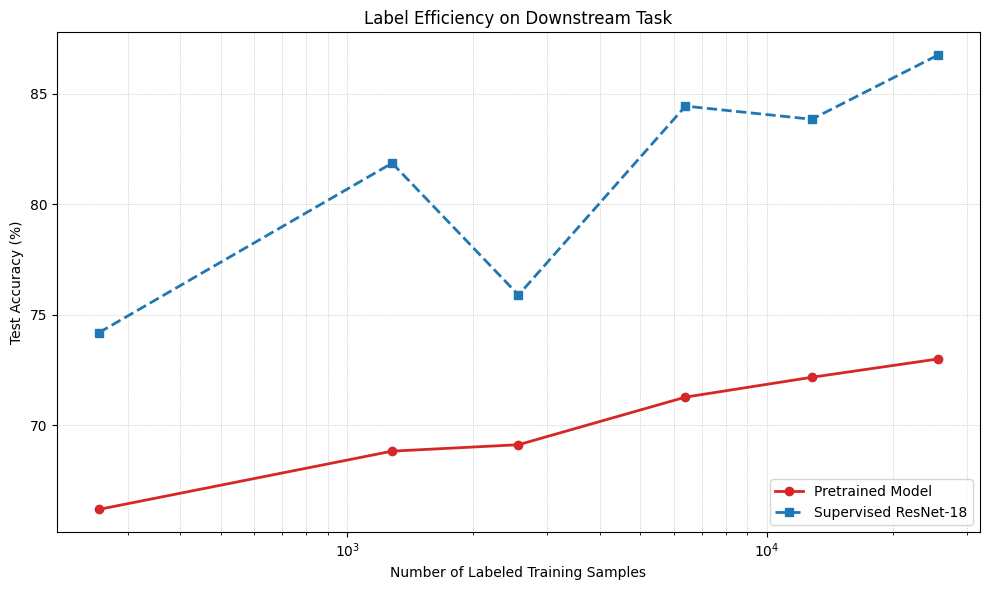

In [45]:
train_dataset = SleepEDF_Evaluation_Dataset(split="train")
test_loader = DataLoader(SleepEDF_Evaluation_Dataset(split="test"), batch_size=128, shuffle=False)

plot_label_efficiency_experiment(
    train_dataset=train_dataset,
    test_loader=test_loader,
    device=DEVICE,
    fractions=[0.01, 0.05, 0.10, 0.25, 0.50, 1.0],
    #eval_epochs=30
)

In [40]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import os
# Get the directory where the script is located
BASE_DIR = os.path.dirname(os.path.abspath("/home/gella.saikrishna/code/Learning-with-FrameProjections"))
ckpt_path = os.path.join(BASE_DIR, "checkpoints", "new_best_time_encoder.pth")

os.chdir("/home/gella.saikrishna/code/Learning-with-FrameProjections")
def get_subset_loader(dataset, fraction, batch_size=128):
    subset_size = int(len(dataset) * fraction)
    indices = np.random.choice(len(dataset), subset_size, replace=False)
    subset = Subset(dataset, indices)
    return DataLoader(subset, batch_size=batch_size, shuffle=True)

def train_and_eval_pretrained(train_loader, test_loader, device):
    # 1. Initialize full architecture components
    args = type('Args', (object,), {'wo_OB': False, 'wo_OF': False})()
    
    time_encoder = ResNet1D(
        in_channels=1, base_filters=32, kernel_size=5, stride=1, groups=1, 
        n_block=3, n_classes=LATENT_DIM, downsample_gap=2, increasefilter_gap=4, 
        use_do=True, backbone=True, output_dim=LATENT_DIM
    ).to(device)

    spect_encoder = UNET_2D_simp(
        input_channels=1, output_channels=LATENT_DIM, layer_n=32, 
        spect_freq=64, spect_time=48, kernel_size=3
    )
    spect_encoder.fc = nn.Linear(6, 1)
    spect_encoder.fc2 = nn.Linear(8, 1)
    spect_encoder = spect_encoder.to(device)

    ft_encoder = FourierWrapper(in_length=3000).to(device)

    iso_model = IsoAlign(
        backbone=time_encoder, spect_encoder=spect_encoder, FT_encoder=ft_encoder, 
        DEVICE=device, dim=LATENT_DIM, batch_size=128, args=args
    ).to(device)

    # 2. Load pre-trained weights
    ckpt_path = "/home/gella.saikrishna/code/Learning-with-FrameProjections/checkpoints/new_best_time_encoder.pth"
    iso_model.load_state_dict(torch.load(ckpt_path, map_location=device))

    encoder = IntegratedEncoder(
        model=iso_model,
        map_ft=iso_model.predictor_FT,
        map_cwt=iso_model.predictor_cwt,
        args=args,
        out_dim=LATENT_DIM
    ).to(device)

    for param in encoder.parameters():
        param.requires_grad = False

    # 3. Setup Classifier Head (Matches concatenated output: LATENT_DIM * 3)
    classifier_head = nn.Linear(LATENT_DIM * 3, NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(classifier_head.parameters(), lr=1e-2, weight_decay=1e-4)

    # 4. Training loop
    for epoch in range(30):
        encoder.eval()
        classifier_head.train()
        for signals, labels in train_loader:
            signals, labels = signals.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.no_grad():
                _, features = encoder(signals)
            loss = criterion(classifier_head(features), labels)
            loss.backward()
            optimizer.step()
            
    # 5. Evaluation
    encoder.eval()
    classifier_head.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for signals, labels in test_loader:
            signals = signals.to(device)
            _, features = encoder(signals)
            outputs = classifier_head(features)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())
            
    return accuracy_score(all_targets, all_preds) * 100
def train_and_eval_supervised(train_loader, test_loader, device):
    model = ResNet1D(
        in_channels=1, base_filters=32, kernel_size=5, stride=1, groups=1, 
        n_block=3, n_classes=NUM_CLASSES, downsample_gap=2, increasefilter_gap=4, 
        use_do=True, backbone=False
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    
    for epoch in range(30):
        model.train()
        for signals, labels in train_loader:
            signals, labels = signals.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs, _ = model(signals)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    model.eval()
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for signals, labels in test_loader:
            signals = signals.to(device)
            outputs, _ = model(signals)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())
            
    acc = accuracy_score(all_targets, all_preds)
    return acc * 100

def plot_label_efficiency_experiment(train_dataset, test_loader, device, fractions=[0.01, 0.05, 0.10, 0.25, 0.50, 1.0]):
    label_counts = []
    acc_pretrained = []
    acc_supervised = []
    
    for frac in fractions:
        print(f"\n--- Training with Fraction: {frac} ---")
        
        train_loader = get_subset_loader(train_dataset, frac)
        label_counts.append(len(train_loader.dataset))
        
        acc_pt = train_and_eval_pretrained(train_loader, test_loader, device)
        print(f"Pretrained Model Accuracy for fraction {frac}: {acc_pt:.2f}%")
        acc_pretrained.append(acc_pt)
        
        acc_sup = train_and_eval_supervised(train_loader, test_loader, device)
        print(f"Supervised Model Accuracy for fraction {frac}: {acc_sup:.2f}%")
        acc_supervised.append(acc_sup)

    plt.figure(figsize=(10, 6))
    plt.plot(label_counts, acc_pretrained, marker='o', color='tab:red', linewidth=2, label='Pretrained Model')
    plt.plot(label_counts, acc_supervised, marker='s', color='tab:blue', linewidth=2, linestyle='--', label='Supervised ResNet-18')
    
    plt.xscale('log')
    plt.xlabel('Number of Labeled Training Samples')
    plt.ylabel('Test Accuracy (%)')
    plt.title('Label Efficiency on Downstream Task')
    plt.grid(True, which='both', linestyle=':', linewidth=0.5)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

Loading data for evaluation split 'train'...
   Loaded 25612 windows | Final sample shape: torch.Size([25612, 3000, 1])
Loading data for evaluation split 'test'...
   Loaded 8910 windows | Final sample shape: torch.Size([8910, 3000, 1])

--- Training with Fraction: 0.01 ---
Pretrained Model Accuracy for fraction 0.01: 74.38%
Supervised Model Accuracy for fraction 0.01: 55.25%

--- Training with Fraction: 0.05 ---
Pretrained Model Accuracy for fraction 0.05: 77.63%
Supervised Model Accuracy for fraction 0.05: 76.89%

--- Training with Fraction: 0.1 ---
Pretrained Model Accuracy for fraction 0.1: 78.36%
Supervised Model Accuracy for fraction 0.1: 77.96%

--- Training with Fraction: 0.25 ---
Pretrained Model Accuracy for fraction 0.25: 81.17%
Supervised Model Accuracy for fraction 0.25: 83.38%

--- Training with Fraction: 0.5 ---
Pretrained Model Accuracy for fraction 0.5: 81.90%
Supervised Model Accuracy for fraction 0.5: 82.84%

--- Training with Fraction: 1.0 ---
Pretrained Model Accur

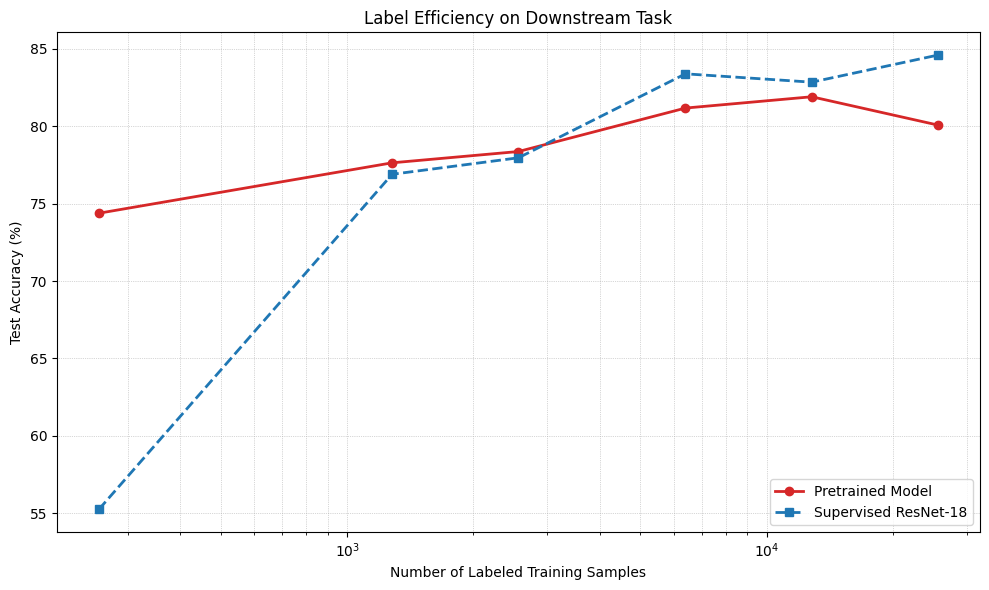

In [41]:
train_dataset = SleepEDF_Evaluation_Dataset(split="train")
test_loader = DataLoader(SleepEDF_Evaluation_Dataset(split="test"), batch_size=128, shuffle=False)

plot_label_efficiency_experiment(
    train_dataset=train_dataset,
    test_loader=test_loader,
    device=DEVICE,
    fractions=[0.01, 0.05, 0.10, 0.25, 0.50, 1.0],
    #eval_epochs=30
)

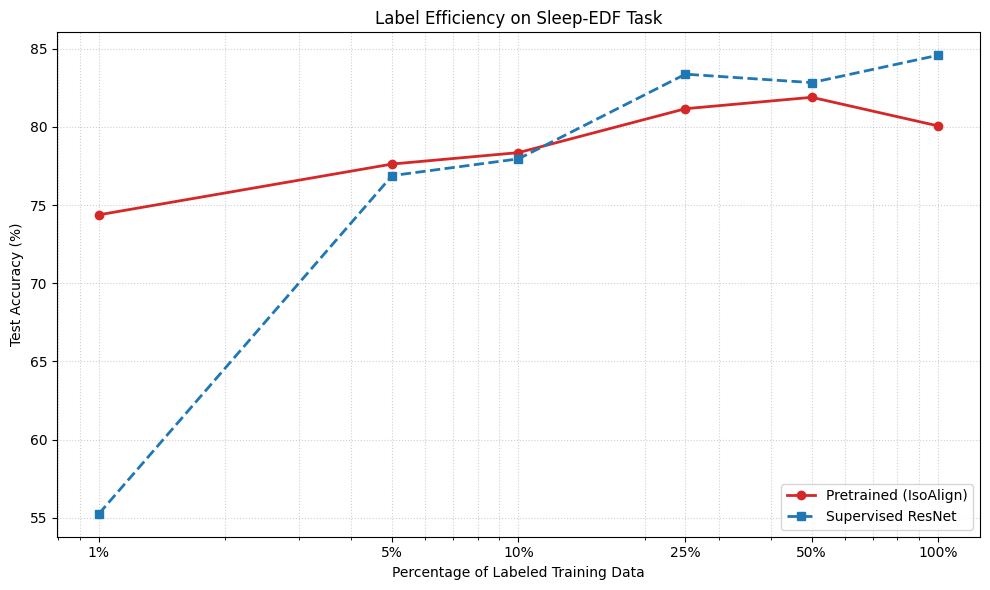

In [43]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Data
fractions = [0.01, 0.05, 0.1, 0.25, 0.5, 1.0]
label_labels = ['1%', '5%', '10%', '25%', '50%', '100%']

acc_pretrained = [74.38, 77.63, 78.36, 81.17, 81.90, 80.07]
acc_supervised = [55.25, 76.89, 77.96, 83.38, 82.84, 84.59]

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(fractions, acc_pretrained, marker='o', linestyle='-', color='tab:red', 
         label='Pretrained (IsoAlign)', linewidth=2)
plt.plot(fractions, acc_supervised, marker='s', linestyle='--', color='tab:blue', 
         label='Supervised ResNet', linewidth=2)

# Set x-axis to log scale and custom labels
plt.xscale('log')
plt.xticks(fractions, label_labels)

plt.xlabel('Percentage of Labeled Training Data')
plt.ylabel('Test Accuracy (%)')
plt.title('Label Efficiency on Sleep-EDF Task')
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

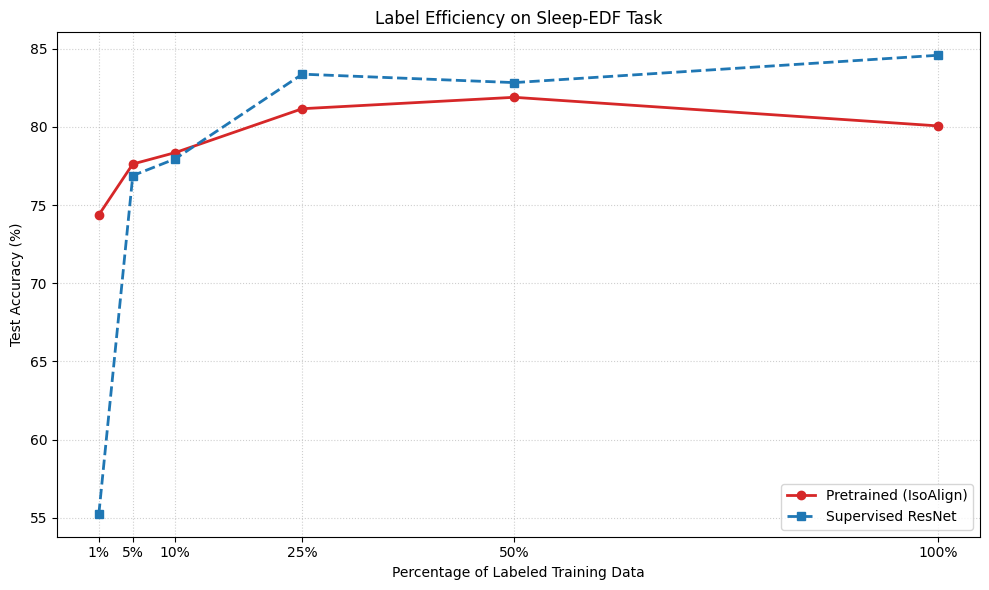

In [3]:
import matplotlib.pyplot as plt

# Data
fractions = [0.01, 0.05, 0.1, 0.25, 0.5, 1.0]
label_labels = ['1%', '5%', '10%', '25%', '50%', '100%']

acc_pretrained = [74.38, 77.63, 78.36, 81.17, 81.90, 80.07]
acc_supervised = [55.25, 76.89, 77.96, 83.38, 82.84, 84.59]

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(fractions, acc_pretrained, marker='o', linestyle='-', color='tab:red', 
         label='Pretrained (IsoAlign)', linewidth=2)
plt.plot(fractions, acc_supervised, marker='s', linestyle='--', color='tab:blue', 
         label='Supervised ResNet', linewidth=2)

# Set the x-ticks exactly at the mathematical fractions
# We DO NOT use plt.xscale('log') here, defaulting to a linear scale
plt.xticks(fractions, label_labels)

plt.xlabel('Percentage of Labeled Training Data')
plt.ylabel('Test Accuracy (%)')
plt.title('Label Efficiency on Sleep-EDF Task')
plt.grid(True, which='major', linestyle=':', alpha=0.6)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()